In [1]:
import sys
sys.path.append("/Users/tdinelli/Documents/GitHub/diffPLOG2TROE")

import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from diffPLOG2TROE.rate_constants import FallOff, Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter

## HNO2 = HONO

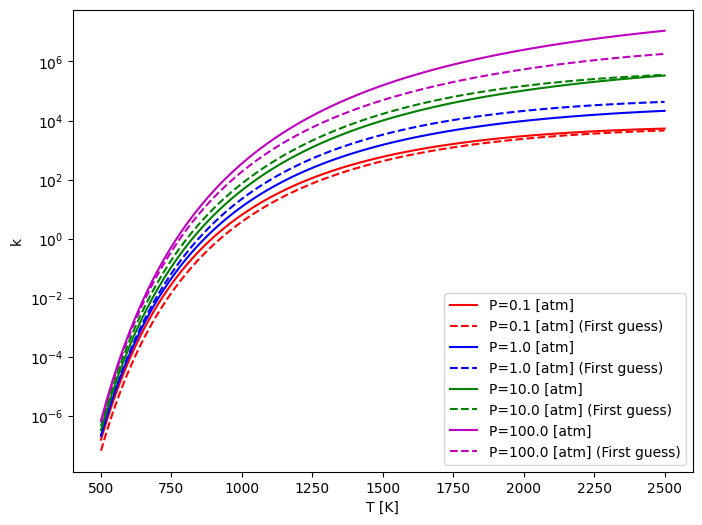

In [2]:
plog = {
    "name": "HNO2=HONO",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            # [0.01, 3.260000e+34, -7.97, 45490.0],
            [0.1,  2.770000e+33, -7.58, 45250.0],
            [0.316, 1.930000e+32, -7.18, 44940.0],
            [1.0,  1.560000e+30, -6.47, 44360.0],
            [3.16, 2.170000e+27, -5.49, 43670.0],
            [10.0, 4.680000e+24, -4.52, 43320.0],
            [31.6, 1.140000e+23, -3.81, 43640.0],
            [100.0, 2.030000e+22, -3.35, 44430.0]
        ]
    }
}
constant = Plog(plog)

# These values are the one computed directly by the refitter class as its shown in the next cells
troe = FallOff(
    name="HNO2(+M)=HONO(+M)",
    hpl_params=jnp.array([2.030e+22, -3.350, 4.443e+04]),
    lpl_params=jnp.array([2.273e+36, -6.580, 4.525e+04]),
    falloff_params=jnp.array([0.500, 1.050e+03, 3.000e+02, 2.250e+03, 0.]),
    falloff_type=1
)

T_range = jnp.linspace(500, 2500, 100)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 100)
P_levels = jnp.array([0.1, 1, 10, 100])

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = constant.kinetic_constant(T_range, P_levels)
k_troe = troe.kinetic_constant(T_range, P_levels)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["r", "b", "g", "m", "c"]

for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_troe)):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")
    ax.plot(T_range, ki_troe, '--', color=colors[i], label=f"P={P_levels[i]} [atm] (First guess)")
    
ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
plt.show()

In [11]:
refitter = PlogRefitter(
    plog_dict=plog,
    T_range=(T_range[0], T_range[-1]),
    P_range=(P_range[0], P_range[-1]),
    fitting_mode="single",
    primary_falloff_type="troe",
    log_name="HONO2__HONO.log",
    loss_name="robust_rmsle",
)
results = refitter.optimize(
    max_iterations=300,
    uncertainty_factor=0.5,
    uncertainty_type="symmetric",
    tol=1e-10,
)

Plog to troe refitter
 Temperature range [K]: (Array(500., dtype=float64), Array(2500., dtype=float64))
 Pressure range [atm]: (Array(0.1, dtype=float64), Array(100., dtype=float64))
 Loss function: robust_rmsle

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: optimizing from default initial value
  n_high: optimizing from default initial value
  E_high: optimizing from default initial value
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value

Estimating initial parameters:
Troe parameters
  High pressure limit (A, n, Ea): 2.030e+22, -3.350, 4.443e+04
  Low pressure limit (A, n, Ea): 2.273e+36, -6.580, 4.525e+04
  Troe parameters (A, T3, T1, T2): 0.500, 1.050e+03, 3.000e+02, 2.250e+03


Calculating optimization bounds (uncertainty factor:

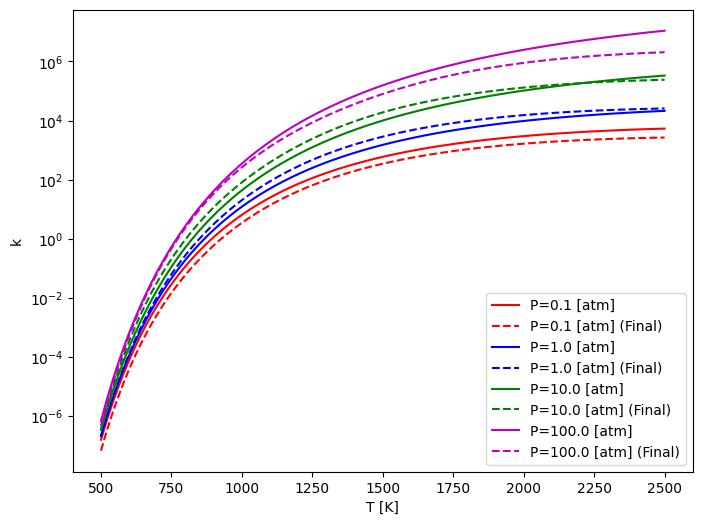

HNO2(+M)=HONO(+M)		3.16292e+17 -1.60903 4.44163e+04
 LOW / 		7.47762e+38 -7.39458 4.52176e+04 /
 TROE / 1.00000e+00 1.04623e+03 4.14800e+02 2.27622e+03 /


In [12]:
params = results["optimized_params"]
troe = FallOff(
    name="HNO2(+M)=HONO(+M)",
    lpl_params=jnp.array([jnp.exp(params[0]), params[1], params[2]*1.987]),
    hpl_params=jnp.array([jnp.exp(params[3]), params[4], params[5]*1.987]),
    falloff_params=jnp.array([params[6], params[7], params[8], params[9], 0]),
    falloff_type=1
)

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = constant.kinetic_constant(T_range, P_levels)
k_troe = troe.kinetic_constant(T_range, P_levels)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["r", "b", "g", "m", "c"]

for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_troe)):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")
    ax.plot(T_range, ki_troe, '--', color=colors[i], label=f"P={P_levels[i]} [atm] (Final)")
    
ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
plt.show()

print(troe)

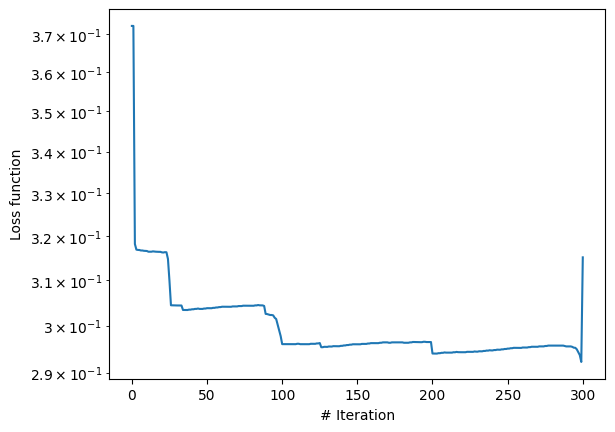

In [13]:
plt.semilogy(results["loss_history"])
plt.xlabel("# Iteration")
plt.ylabel("Loss function")
plt.show()

Minimum error: 0.1871244679228816
Maximum error: 2.2763247143568126
Average error: 0.44370057814718195


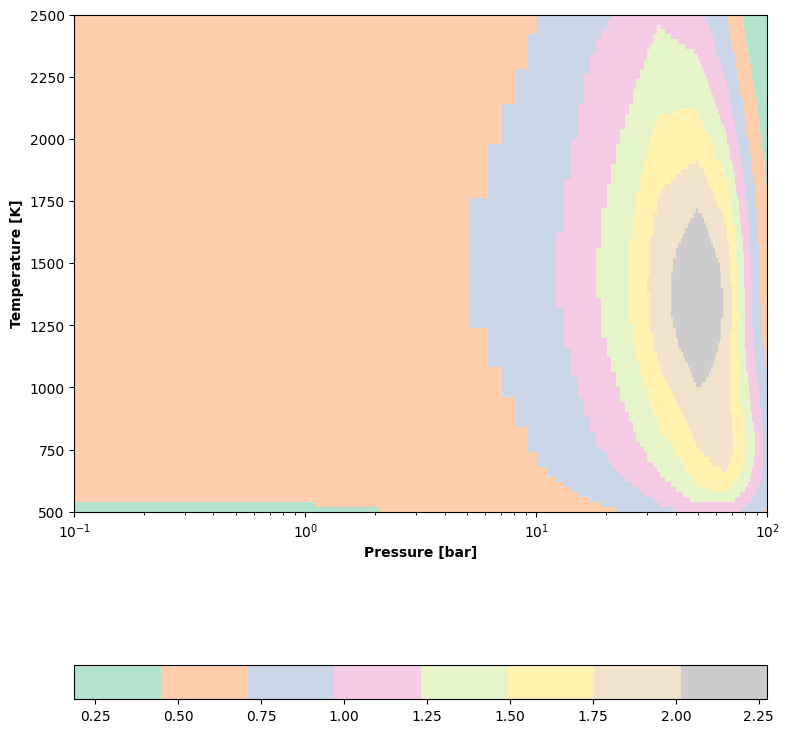

In [14]:
T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

k_plog = constant.kinetic_constant(T_range, P_range)
k_troe = troe.kinetic_constant(T_range, P_range)

ratio = k_troe.T / k_plog.T
rel_ratio = jnp.mean(jnp.sqrt((1 - k_troe.T / k_plog.T) ** 2))

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="Pastel2"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {rel_ratio}")

plt.tight_layout()
plt.show()